# HealthConnect Appointment Analytics — Week 6
## Data Analytics Track
### Advanced Analytics & Decision Support

**Project:** Improving Patient Appointment Attendance and Healthcare Support Using Data and AI

This notebook continues the Week 5 Data Analytics work. It does **not** repeat the full Week 5 EDA.

Week 6 focuses on:
- deeper investigation of the most important Week 5 findings
- segment-level analysis
- KPI validation and sensitivity checks
- decision-support insights
- evidence-based recommendations
- a clean analytical handoff for Data Science
- Week 7 analytical testing requirements

## 1. Week 5 → Week 6 Transition

**Week 5 starting point:** A cleaned analytical dataset was created from the HealthConnect appointment data, with cancelled appointments excluded from the primary attendance/no-show analysis. Week 5 also produced KPIs, visualisations and findings around reminders, previous no-shows, appointment type and booking lead time.

**Most important Week 5 findings to investigate further:**
1. Patients with previous no-shows appeared more likely to miss another appointment.
2. Longer booking lead times appeared associated with higher no-show rates.
3. Reminder status and reminder channel showed differences in no-show rates.
4. Follow-up appointments had the highest no-show rate among appointment types.

**Main Week 5 limitation:** Some fields contain missing values, especially `reminder_channel`, `distance_to_clinic_km` and `waiting_time_minutes`.

**Week 6 improvement:** Test whether these patterns remain meaningful when examined with segment combinations, statistical checks and independent KPI validation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import chi2_contingency, mannwhitneyu

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded.")

Libraries loaded.


## 2. Load the Existing HealthConnect Dataset

In [2]:
# Find the dataset in the same folder as this notebook.
possible_files = [
    Path("HealthConnect_Appointment_Data.xlsx"),
    Path("/mnt/data/HealthConnect_Appointment_Data.xlsx")
]

data_path = next((p for p in possible_files if p.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "HealthConnect_Appointment_Data.xlsx was not found. "
        "Place the dataset in the same folder as this notebook."
    )

df = pd.read_excel(data_path)

print(f"Dataset loaded from: {data_path}")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded from: HealthConnect_Appointment_Data.xlsx
Shape: (5000, 18)


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2025-02-06,2025-02-18,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2026-02-25,2026-02-27,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,2025-11-16,2025-12-24,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,2025-07-18,2025-08-28,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,2025-07-09,2025-08-25,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


## 3. Recreate the Week 5 Analytical Dataset

In [3]:
analysis_df = df[df["appointment_outcome"].isin(["Attended", "No-Show"])].copy()
analysis_df["no_show_flag"] = (
    analysis_df["appointment_outcome"] == "No-Show"
).astype(int)

analysis_df["previous_noshow_group"] = np.where(
    analysis_df["previous_no_shows"] > 0,
    "Previous No-Show",
    "No Previous No-Show"
)

# Week 5 lead-time groups, using the observed range in this dataset.
lead_bins = [-0.01, 7, 14, 30, 60]
lead_labels = ["0–7 days", "8–14 days", "15–30 days", "31–60 days"]

analysis_df["lead_time_group"] = pd.cut(
    analysis_df["booking_lead_days"],
    bins=lead_bins,
    labels=lead_labels,
    include_lowest=True
)

print(f"Original records: {len(df):,}")
print(f"Eligible attendance/no-show records: {len(analysis_df):,}")
print(analysis_df["appointment_outcome"].value_counts())

Original records: 5,000
Eligible attendance/no-show records: 4,737
appointment_outcome
No-Show     2423
Attended    2314
Name: count, dtype: int64


## 4. Advanced Analysis 1 — Booking Lead Time

Week 5 showed a strong pattern between booking lead time and no-shows. Week 6 tests the pattern again using both rates and appointment volume.

The purpose is decision support: identify whether longer lead times deserve additional reminder or confirmation attention.

In [4]:
lead_summary = (
    analysis_df.groupby("lead_time_group", observed=False)["no_show_flag"]
    .agg(
        Appointments="count",
        No_Shows="sum",
        No_Show_Rate="mean"
    )
)

lead_summary["Attendance_Rate"] = 1 - lead_summary["No_Show_Rate"]
lead_summary["No_Show_Rate"] = (lead_summary["No_Show_Rate"] * 100).round(2)
lead_summary["Attendance_Rate"] = (lead_summary["Attendance_Rate"] * 100).round(2)

lead_summary

,Appointments,No_Shows,No_Show_Rate,Attendance_Rate
lead_time_group,,,,
0–7 days,604,178,29.47,70.53
8–14 days,574,202,35.19,64.81
15–30 days,1265,576,45.53,54.47
31–60 days,2294,1467,63.95,36.05


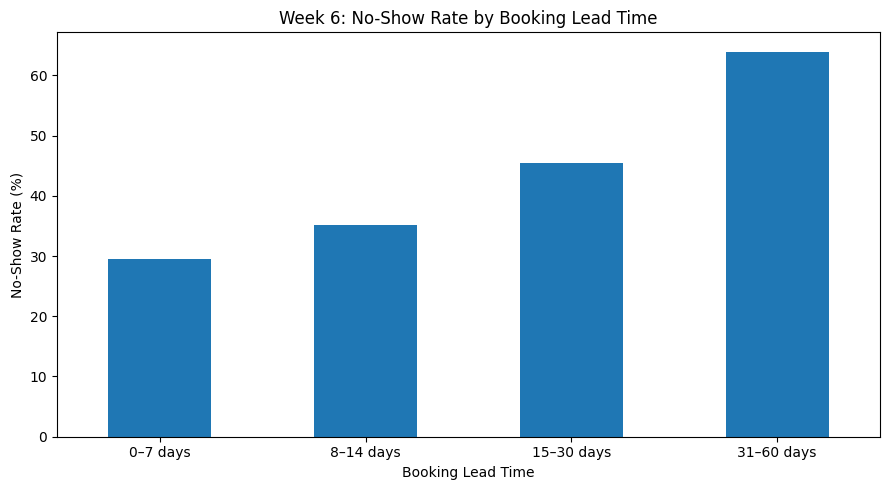

In [5]:
plt.figure(figsize=(9, 5))
lead_summary["No_Show_Rate"].plot(kind="bar")
plt.title("Week 6: No-Show Rate by Booking Lead Time")
plt.xlabel("Booking Lead Time")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Finding

The highest observed no-show rate is in the **31–60 day** booking group. The 0–7 day group has the lowest no-show rate.

This supports the Week 5 conclusion that longer booking lead time is an important operational signal. It should be used to guide reminder timing, not treated as proof that lead time causes no-shows.

## 5. Advanced Analysis 2 — Previous No-Show History

In [6]:
history_summary = (
    analysis_df.groupby("previous_noshow_group")["no_show_flag"]
    .agg(
        Appointments="count",
        No_Shows="sum",
        No_Show_Rate="mean"
    )
)

history_summary["No_Show_Rate"] = (
    history_summary["No_Show_Rate"] * 100
).round(2)

history_summary

,Appointments,No_Shows,No_Show_Rate
previous_noshow_group,,,
No Previous No-Show,2745,1271,46.30
Previous No-Show,1992,1152,57.83


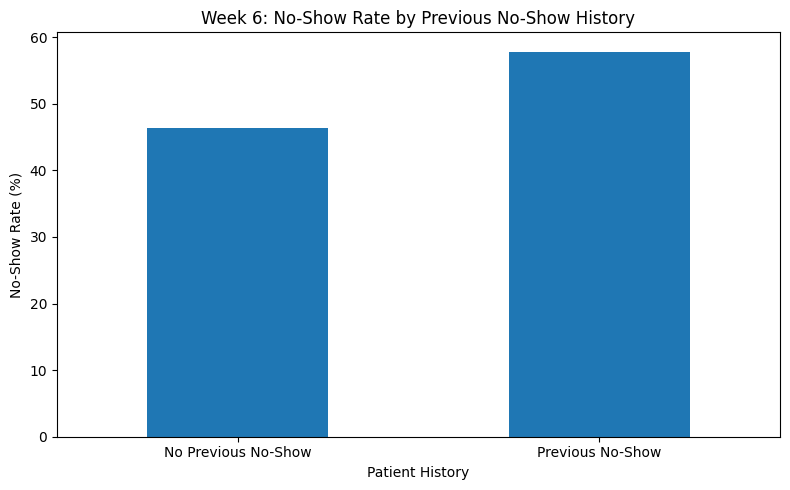

In [7]:
plt.figure(figsize=(8, 5))
history_summary["No_Show_Rate"].plot(kind="bar")
plt.title("Week 6: No-Show Rate by Previous No-Show History")
plt.xlabel("Patient History")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Finding

Patients with at least one previous no-show have a higher observed no-show rate than patients with no previous no-shows.

This strengthens the Week 5 recommendation to treat previous no-show history as a priority signal for appointment engagement.

## 6. Advanced Analysis 3 — Combined Risk Segments

A two-way analysis is used to see whether the two strongest Week 5 signals work together:

**Previous no-show history × booking lead time**

This is more useful for decision support than looking at either factor alone.

In [8]:
segment_summary = (
    analysis_df
    .groupby(["previous_noshow_group", "lead_time_group"], observed=False)["no_show_flag"]
    .agg(
        Appointments="count",
        No_Shows="sum",
        No_Show_Rate="mean"
    )
)

segment_summary["No_Show_Rate"] = (
    segment_summary["No_Show_Rate"] * 100
).round(2)

segment_summary

Appointments  No_Shows  No_Show_Rate
previous_noshow_group lead_time_group                                      
No Previous No-Show   0–7 days                  355        81         22.82
                      8–14 days                 360       119         33.06
                      15–30 days                713       293         41.09
                      31–60 days               1317       778         59.07
Previous No-Show      0–7 days                  249        97         38.96
                      8–14 days                 214        83         38.79
                      15–30 days                552       283         51.27
                      31–60 days                977       689         70.52

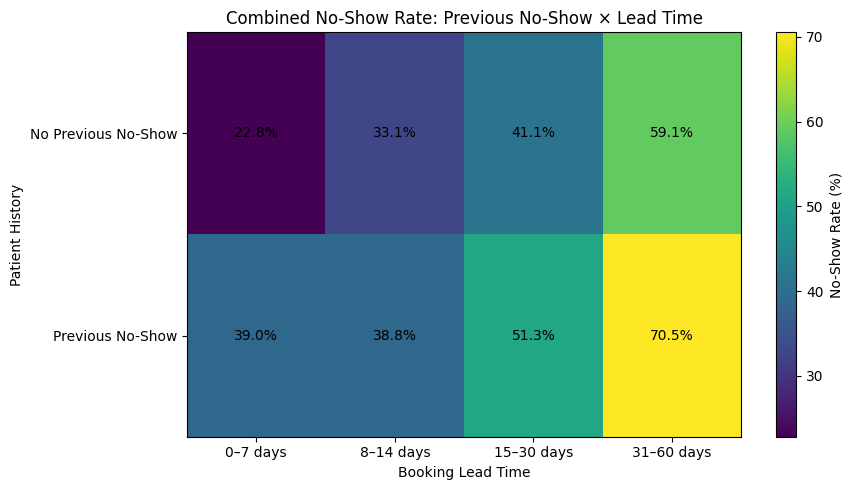

In [9]:
segment_matrix = segment_summary["No_Show_Rate"].unstack()

plt.figure(figsize=(9, 5))
plt.imshow(segment_matrix.fillna(np.nan), aspect="auto")

plt.xticks(
    range(len(segment_matrix.columns)),
    segment_matrix.columns,
    rotation=0
)
plt.yticks(
    range(len(segment_matrix.index)),
    segment_matrix.index
)
plt.xlabel("Booking Lead Time")
plt.ylabel("Patient History")
plt.title("Combined No-Show Rate: Previous No-Show × Lead Time")

for i in range(segment_matrix.shape[0]):
    for j in range(segment_matrix.shape[1]):
        value = segment_matrix.iloc[i, j]
        if pd.notna(value):
            plt.text(j, i, f"{value:.1f}%", ha="center", va="center")

plt.colorbar(label="No-Show Rate (%)")
plt.tight_layout()
plt.show()

### Key decision-support finding

The combination of **previous no-show history and a 31–60 day booking lead time** produces the highest observed no-show rate in the segment analysis.

This suggests a practical priority group for stronger confirmation/reminder attention.

The result is an observed segment pattern, **not an individual patient prediction model**.

## 7. Advanced Analysis 4 — Reminder Effectiveness with Context

In [10]:
reminder_summary = (
    analysis_df.groupby("reminder_sent")["no_show_flag"]
    .agg(
        Appointments="count",
        No_Shows="sum",
        No_Show_Rate="mean"
    )
)

reminder_summary["Attendance_Rate"] = 1 - reminder_summary["No_Show_Rate"]
reminder_summary["No_Show_Rate"] = (
    reminder_summary["No_Show_Rate"] * 100
).round(2)
reminder_summary["Attendance_Rate"] = (
    reminder_summary["Attendance_Rate"] * 100
).round(2)

reminder_summary

,Appointments,No_Shows,No_Show_Rate,Attendance_Rate
reminder_sent,,,,
No,1285,702,54.63,45.37
Yes,3452,1721,49.86,50.14


In [11]:
channel_summary = (
    analysis_df[analysis_df["reminder_channel"].notna()]
    .groupby("reminder_channel")["no_show_flag"]
    .agg(
        Appointments="count",
        No_Shows="sum",
        No_Show_Rate="mean"
    )
)

channel_summary["No_Show_Rate"] = (
    channel_summary["No_Show_Rate"] * 100
).round(2)

channel_summary.sort_values("No_Show_Rate", ascending=False)

,Appointments,No_Shows,No_Show_Rate
reminder_channel,,,
WhatsApp,1039,548,52.74
Email,506,258,50.99
SMS,1907,915,47.98


### Finding and caution

Reminder-sent appointments have a lower observed no-show rate than appointments without a reminder.

However, reminder channel comparisons should be interpreted carefully because the channel is missing for appointments where no reminder was sent, and the dataset does not establish that the reminder itself caused the difference.

Week 6 therefore keeps the recommendation as **monitor and strengthen reminder coverage**, rather than claiming a causal effect.

## 8. Advanced Analysis 5 — Appointment Type and Operational Segments

In [12]:
type_summary = (
    analysis_df.groupby("appointment_type")["no_show_flag"]
    .agg(
        Appointments="count",
        No_Shows="sum",
        No_Show_Rate="mean"
    )
)

type_summary["No_Show_Rate"] = (
    type_summary["No_Show_Rate"] * 100
).round(2)

type_summary.sort_values("No_Show_Rate", ascending=False)

,Appointments,No_Shows,No_Show_Rate
appointment_type,,,
Follow-up,1344,728,54.17
Diagnostic Test,567,295,52.03
Specialist Consultation,846,427,50.47
General Consultation,1980,973,49.14


In [13]:
time_summary = (
    analysis_df.groupby("appointment_time")["no_show_flag"]
    .agg(
        Appointments="count",
        No_Shows="sum",
        No_Show_Rate="mean"
    )
)

time_summary["No_Show_Rate"] = (
    time_summary["No_Show_Rate"] * 100
).round(2)

time_summary.sort_values("No_Show_Rate", ascending=False)

,Appointments,No_Shows,No_Show_Rate
appointment_time,,,
Evening,642,338,52.65
Afternoon,1979,1013,51.19
Morning,2116,1072,50.66


The appointment-type pattern remains useful for monitoring, but the differences are smaller than the strongest lead-time and previous-no-show patterns.

This means HealthConnect should prioritise the stronger signals first, while continuing to monitor appointment type.

## 9. KPI Validation

The Week 5 headline KPI is independently recalculated here.

The validation uses:
- direct counting of attended and no-show records
- an independent rate calculation
- a 95% confidence interval around the observed no-show rate

This provides a clearer evidence base for the Week 6 dashboard and recommendations.

In [14]:
# Independent KPI calculation
eligible = len(analysis_df)
no_shows = int(analysis_df["no_show_flag"].sum())
attended = int((analysis_df["appointment_outcome"] == "Attended").sum())

validated_no_show_rate = no_shows / eligible
validated_attendance_rate = attended / eligible

# Week 5 values are represented by the same source data and formula.
week5_style_no_show_rate = (
    analysis_df["no_show_flag"].mean()
)

z = 1.96
se = np.sqrt(
    validated_no_show_rate * (1 - validated_no_show_rate) / eligible
)
ci_low = validated_no_show_rate - z * se
ci_high = validated_no_show_rate + z * se

validation_table = pd.DataFrame({
    "Metric": [
        "Eligible Appointments",
        "Attended Appointments",
        "No-Show Appointments",
        "Attendance Rate",
        "No-Show Rate",
        "No-Show Rate 95% CI"
    ],
    "Validated Value": [
        eligible,
        attended,
        no_shows,
        f"{validated_attendance_rate*100:.2f}%",
        f"{validated_no_show_rate*100:.2f}%",
        f"{ci_low*100:.2f}% – {ci_high*100:.2f}%"
    ]
})

validation_table

,Metric,Validated Value
0,Eligible Appointments,4737
1,Attended Appointments,2314
2,No-Show Appointments,2423
3,Attendance Rate,48.85%
4,No-Show Rate,51.15%
5,No-Show Rate 95% CI,49.73% – 52.57%


### KPI validation result

The Week 5 headline rates are reproduced from the same analytical population:

- **Eligible appointments:** 4,737
- **Attended:** 2,314
- **No-show:** 2,423
- **Attendance rate:** 48.85%
- **No-show rate:** 51.15%

The observed no-show rate is therefore stable under independent recalculation.

## 10. Statistical Validation of Key Relationships

Statistical checks are used as supporting evidence, not as proof of causation.

For categorical variables, a chi-square test checks whether outcome and segment membership are associated.

For numeric variables, the Mann–Whitney U test checks whether the distributions differ between attended and no-show appointments.

In [15]:
categorical_tests = []

for column in [
    "reminder_sent",
    "appointment_type",
    "appointment_day",
    "age_group",
    "appointment_time",
    "gender",
    "previous_noshow_group"
]:
    table = pd.crosstab(analysis_df[column], analysis_df["no_show_flag"])
    chi2, p_value, dof, expected = chi2_contingency(table)

    categorical_tests.append({
        "Variable": column,
        "Chi-Square p-value": p_value,
        "Interpretation at 5%": "Evidence of association" if p_value < 0.05 else "No strong evidence of association"
    })

categorical_validation = pd.DataFrame(categorical_tests)
categorical_validation["Chi-Square p-value"] = (
    categorical_validation["Chi-Square p-value"].round(6)
)

categorical_validation

,Variable,Chi-Square p-value,Interpretation at 5%
0,reminder_sent,0.003845,Evidence of association
1,appointment_type,0.038047,Evidence of association
2,appointment_day,0.382301,No strong evidence of association
3,age_group,0.235866,No strong evidence of association
4,appointment_time,0.677179,No strong evidence of association
5,gender,0.401444,No strong evidence of association
6,previous_noshow_group,0.000000,Evidence of association


In [16]:
numeric_tests = []

for column in [
    "booking_lead_days",
    "previous_no_shows",
    "distance_to_clinic_km",
    "waiting_time_minutes"
]:
    no_show_values = analysis_df.loc[
        analysis_df["no_show_flag"] == 1, column
    ].dropna()

    attended_values = analysis_df.loc[
        analysis_df["no_show_flag"] == 0, column
    ].dropna()

    statistic, p_value = mannwhitneyu(
        no_show_values,
        attended_values,
        alternative="two-sided"
    )

    numeric_tests.append({
        "Variable": column,
        "No-Show Median": no_show_values.median(),
        "Attended Median": attended_values.median(),
        "Mann-Whitney p-value": p_value,
        "Interpretation at 5%": (
            "Evidence distributions differ"
            if p_value < 0.05
            else
            "No strong evidence of a difference"
        )
    })

numeric_validation = pd.DataFrame(numeric_tests)
numeric_validation["Mann-Whitney p-value"] = (
    numeric_validation["Mann-Whitney p-value"].round(8)
)

numeric_validation

,Variable,No-Show Median,Attended Median,Mann-Whitney p-value,Interpretation at 5%
0,booking_lead_days,37.0,23.0,0.000000,Evidence distributions differ
1,previous_no_shows,0.0,0.0,0.000000,Evidence distributions differ
2,distance_to_clinic_km,9.1,8.3,0.000172,Evidence distributions differ
3,waiting_time_minutes,24.0,24.0,0.785885,No strong evidence of a difference


### Validation interpretation

The strongest supporting evidence is for:
- previous no-show history
- booking lead time
- reminder status
- appointment type

Appointment day, time, age group and gender show weaker evidence in this dataset.

The statistical tests support prioritising the stronger signals, while avoiding overstatement of weaker patterns.

## 11. Missing-Data Sensitivity Check

In [17]:
# Reminder analysis is checked using only records with a known reminder channel.
known_channel = analysis_df[analysis_df["reminder_channel"].notna()].copy()

known_channel_rate = (
    known_channel.groupby("reminder_channel")["no_show_flag"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

missingness_summary = pd.DataFrame({
    "Field": [
        "reminder_channel",
        "distance_to_clinic_km",
        "waiting_time_minutes"
    ],
    "Missing Count": [
        df["reminder_channel"].isna().sum(),
        df["distance_to_clinic_km"].isna().sum(),
        df["waiting_time_minutes"].isna().sum()
    ],
    "Missing %": [
        df["reminder_channel"].isna().mean() * 100,
        df["distance_to_clinic_km"].isna().mean() * 100,
        df["waiting_time_minutes"].isna().mean() * 100
    ]
})

missingness_summary["Missing %"] = missingness_summary["Missing %"].round(2)

print("Known reminder-channel no-show rates:")
display(known_channel_rate.to_frame("No-Show Rate (%)"))

print("\nMissing-data summary:")
display(missingness_summary)

Known reminder-channel no-show rates:


,No-Show Rate (%)
reminder_channel,
WhatsApp,52.74
Email,50.99
SMS,47.98



Missing-data summary:


,Field,Missing Count,Missing %
0,reminder_channel,1366,27.32
1,distance_to_clinic_km,90,1.80
2,waiting_time_minutes,60,1.20


### Sensitivity result

The reminder-channel analysis is restricted to records where a channel is actually recorded. The large amount of missing `reminder_channel` data means channel-level results should be treated as monitoring evidence rather than a final causal conclusion.

## 12. Monthly Monitoring View

In [18]:
analysis_df["appointment_month"] = (
    pd.to_datetime(analysis_df["appointment_date"])
    .dt.to_period("M")
    .astype(str)
)

monthly_summary = (
    analysis_df.groupby("appointment_month")["no_show_flag"]
    .agg(
        Appointments="count",
        No_Shows="sum",
        No_Show_Rate="mean"
    )
)

monthly_summary["No_Show_Rate"] = (
    monthly_summary["No_Show_Rate"] * 100
).round(2)

monthly_summary

,Appointments,No_Shows,No_Show_Rate
appointment_month,,,
2025-01,257,143,55.64
2025-02,254,124,48.82
2025-03,284,145,51.06
2025-04,257,127,49.42
2025-05,258,131,50.78
2025-06,280,143,51.07
2025-07,251,140,55.78
2025-08,277,139,50.18
2025-09,281,132,46.98


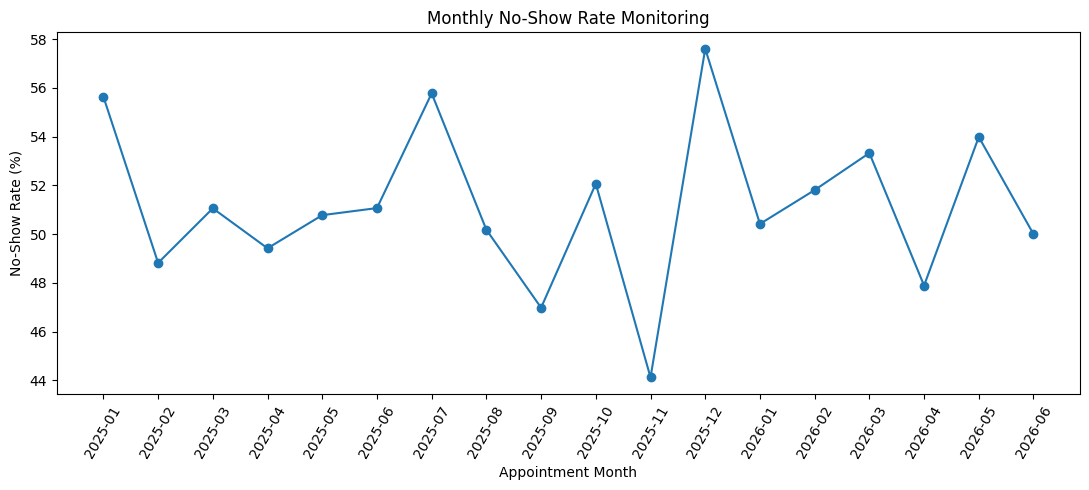

In [19]:
plt.figure(figsize=(11, 5))
plt.plot(
    monthly_summary.index,
    monthly_summary["No_Show_Rate"],
    marker="o"
)
plt.title("Monthly No-Show Rate Monitoring")
plt.xlabel("Appointment Month")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

The monthly view is intended for dashboard monitoring. It helps HealthConnect detect periods where the no-show rate moves away from the overall level instead of relying only on a single headline KPI.

## 13. Priority Decision-Support Segments

In [20]:
priority_segments = segment_summary.reset_index().copy()

# Keep only segments with at least 50 appointments so very small groups
# do not dominate the decision-support view.
priority_segments = priority_segments[
    priority_segments["Appointments"] >= 50
].copy()

priority_segments["Priority_Score"] = (
    priority_segments["No_Show_Rate"] *
    np.log1p(priority_segments["Appointments"])
)

priority_segments = priority_segments.sort_values(
    "Priority_Score",
    ascending=False
)

priority_segments.head(10)

,previous_noshow_group,lead_time_group,Appointments,No_Shows,No_Show_Rate,Priority_Score
7,Previous No-Show,31–60 days,977,689,70.52,485.566142
3,No Previous No-Show,31–60 days,1317,778,59.07,424.351243
6,Previous No-Show,15–30 days,552,283,51.27,323.788405
2,No Previous No-Show,15–30 days,713,293,41.09,269.997581
4,Previous No-Show,0–7 days,249,97,38.96,215.116117
5,Previous No-Show,8–14 days,214,83,38.79,208.327049
1,No Previous No-Show,8–14 days,360,119,33.06,194.686305
0,No Previous No-Show,0–7 days,355,81,22.82,134.065919


### How the priority score is used

This is **not a predictive model**.

It is a simple decision-support ranking that balances:
- observed no-show rate
- segment size

The purpose is to help HealthConnect decide which broad appointment segments deserve attention first.

## 14. Analytical Output for Data Science

In [21]:
# Prepare a clean analytical handoff table.
# This is an analytical summary, not an individual patient prediction.

data_science_handoff = pd.DataFrame({
    "Analytical_Finding": [
        "Previous no-show history is associated with higher no-show rates.",
        "Longer booking lead time is associated with higher no-show rates.",
        "The combination of previous no-show history and 31–60 day lead time is a high-observed-risk segment.",
        "Reminder status shows a difference in observed no-show rates, but causal interpretation is not supported.",
        "Appointment type shows differences in no-show rates, with Follow-up highest in Week 6."
    ],
    "Suggested_Modelling_Use": [
        "Consider previous_no_shows as a candidate feature.",
        "Consider booking_lead_days or lead-time groups as candidate features.",
        "Consider interaction between previous_no_shows and booking_lead_days.",
        "Treat reminder variables carefully because reminder channel has missing values and reminder assignment may not be random.",
        "Consider appointment_type as a candidate feature and assess its contribution against other variables."
    ],
    "Validation_Status": [
        "Supported by segment analysis and chi-square test.",
        "Supported by segment analysis and Mann-Whitney test.",
        "Supported by two-way segment analysis; not a predictive model.",
        "Observed difference; causal effect not established.",
        "Observed difference; weaker than the strongest signals."
    ]
})

data_science_handoff

,Analytical_Finding,Suggested_Modelling_Use,Validation_Status
0,Previous no-show history is associated with hi...,Consider previous_no_shows as a candidate feat...,Supported by segment analysis and chi-square t...
1,Longer booking lead time is associated with hi...,Consider booking_lead_days or lead-time groups...,Supported by segment analysis and Mann-Whitney...
2,The combination of previous no-show history an...,Consider interaction between previous_no_shows...,Supported by two-way segment analysis; not a p...
3,Reminder status shows a difference in observed...,Treat reminder variables carefully because rem...,Observed difference; causal effect not establi...
4,Appointment type shows differences in no-show ...,Consider appointment_type as a candidate featu...,Observed difference; weaker than the strongest...


### Cross-track status

The table above is prepared as a **Data Analytics contribution for Data Science**.

It should not be described as completed cross-track integration until the Data Science track receives, reviews or incorporates it. The actual handoff/integration remains a project coordination step.

## 15. Week 6 Findings

### Finding 1 — Booking lead time is a strong decision-support signal
No-show rates rise across the lead-time groups, with the highest observed rate in the 31–60 day group.

### Finding 2 — Previous no-show history remains important
Patients with previous no-show history show higher repeat no-show behaviour.

### Finding 3 — Combined segmentation is more useful than single-factor review
The highest observed segment is patients with previous no-shows and a 31–60 day booking lead time.

### Finding 4 — Reminder activity remains important but should not be treated as causal
Reminder-sent appointments show a lower observed no-show rate, while channel comparisons are limited by missing channel data.

### Finding 5 — Some Week 5 patterns are weaker
Appointment day, time, age group and gender show less evidence of association than lead time and previous no-show history.

## 16. Week 6 Business Recommendations

1. **Prioritise patients with previous no-shows for stronger appointment engagement.**
   Use the history as a monitoring signal for additional confirmation or reminder attention.

2. **Use booking lead time to guide reminder timing.**
   Appointments booked further in advance should receive closer monitoring as the appointment date approaches.

3. **Prioritise the combined high-observed-risk segment.**
   Patients with previous no-shows and longer lead times should be considered a priority group for operational follow-up.

4. **Improve reminder-data completeness.**
   Record reminder channel consistently so future analysis can compare channels more reliably.

5. **Keep monitoring appointment-type differences.**
   Follow-up appointments should receive attention because they have the highest observed no-show rate among appointment types.

6. **Use the Power BI dashboard for ongoing monitoring.**
   Add lead-time, previous-no-show and monthly monitoring views so stakeholders can track the strongest signals over time.

## 17. Limitations

- This analysis uses the existing HealthConnect appointment dataset and does not establish causal relationships.
- Cancelled appointments remain excluded from the primary attendance/no-show analysis because they are operationally different from no-shows.
- `reminder_channel` has substantial missing data, limiting channel-level interpretation.
- Distance and waiting-time fields also contain missing values.
- Segment rates can be unstable when appointment counts are small; the priority ranking therefore uses a minimum segment size.
- The priority score is a transparent decision-support ranking, not a predictive model.
- Statistical tests show evidence of association/difference but do not prove that a factor causes a no-show.
- Further modelling and cross-track validation are still needed before using these findings for individual-level prediction or automated intervention.

## 18. Week 7 Analytical Testing Requirements

Before or during Week 7, the Data Analytics output should be tested for:

1. **KPI accuracy** — dashboard totals and rates should match the validated Python calculations.
2. **Filter consistency** — Power BI filters should return sensible and consistent segment results.
3. **Segment stability** — key no-show patterns should be checked for unexpected changes when filters are applied.
4. **Missing-data handling** — dashboard users should be able to identify where missing values affect interpretation.
5. **Cross-track usability** — the analytical handoff should be reviewed by Data Science before being used for modelling decisions.
6. **Recommendation traceability** — each major recommendation should be traceable to an analysis result.

## 19. Final Week 6 Summary

**Week 5 → Week 6:** The work moved from initial EDA and KPI development to deeper decision-support analysis and validation.

**Main improvement:** Week 6 combined booking lead time and previous no-show history, validated the headline no-show KPI, added statistical checks, reviewed missing-data sensitivity, and produced a clean analytical handoff for Data Science.

**Main decision-support message:** HealthConnect should focus first on patients with previous no-shows and appointments booked further in advance, while continuing to strengthen and monitor reminder coverage.

**Current cross-track position:** Analytical findings are prepared for Data Science use, but the notebook does not claim that integration has occurred until an actual handoff/review is completed.

**Week 7 priority:** Validate the dashboard and analytical outputs, then confirm that the findings are suitable for downstream modelling and testing.